# Necessary Setup

We are making use of packages developed by the Tabor group as part of our CMCC work, plus some data that should have shipped with Colab. We'll get that installed, our data downloaded, and then we can run our analyses. Run the three cells after this one with Shift + Enter

In [2]:
!pip install git+https://github.com/McCoyGroup/McUtils.git git+https://github.com/McCoyGroup/Psience.git git+https://github.com/Center-for-Mechanical-Control-of-Chem/cmcc-reactions

  Cloning https://github.com/McCoyGroup/McUtils.git to /tmp/pip-req-build-xvak8kfy
  Running command git clone --filter=blob:none --quiet https://github.com/McCoyGroup/McUtils.git /tmp/pip-req-build-xvak8kfy
  Resolved https://github.com/McCoyGroup/McUtils.git to commit f6c45a2b084d246d23eca122ae0bdd427b9cd109
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/McCoyGroup/Psience.git to /tmp/pip-req-build-3ezi7zq9
  Running command git clone --filter=blob:none --quiet https://github.com/McCoyGroup/Psience.git /tmp/pip-req-build-3ezi7zq9
  Resolved https://github.com/McCoyGroup/Psience.git to commit d65df9f5cd2dcf72249c227db3816dca7b5e9e77
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Center-for-Mechanical-Control-of-Chem/cmcc-reactions to /tmp/pip-req-build-jv

In [24]:
!gdown https://drive.google.com/uc?id=1_ct42f1Fj2Tf-0tLEQMc5tn3YneOjfBU
!gdown https://drive.google.com/uc?id=1JPi6sPmYY8QrgkAMn3M_bJ-ilGX_JsDM
!gdown https://drive.google.com/uc?id=1oop7bdGmWieTu4d7XMTucqTN6xkWjcIE
!gdown https://drive.google.com/uc?id=1hGPyli7fJXbfqMAi6cIcAMA4OoizckRz

Downloading...
From (original): https://drive.google.com/uc?id=1_ct42f1Fj2Tf-0tLEQMc5tn3YneOjfBU
From (redirected): https://drive.google.com/uc?id=1_ct42f1Fj2Tf-0tLEQMc5tn3YneOjfBU&confirm=t&uuid=7eefd987-5cb0-4471-904c-6d588cffc4bb
To: /content/d2_int_partial.npz
100% 1.26G/1.26G [00:17<00:00, 74.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JPi6sPmYY8QrgkAMn3M_bJ-ilGX_JsDM
To: /content/methacrylate_fmrd_cylinder.npz
100% 17.3k/17.3k [00:00<00:00, 43.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1oop7bdGmWieTu4d7XMTucqTN6xkWjcIE
To: /content/methacrylate_fmrd_hydrostatic.npz
100% 17.3k/17.3k [00:00<00:00, 32.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hGPyli7fJXbfqMAi6cIcAMA4OoizckRz
To: /content/methacrylate_prod.npz
100% 5.36k/5.36k [00:00<00:00, 14.5MB/s]


In [36]:
from IPython.display import HTML, display

def show_animation(animation):
  display(HTML(animation.to_html().tostring()))

def show_graphics(graphics):
  show_animation(graphics.figure.to_x3d())

# Effects of Pressure on Mechanochemical Reactions

We'll look at three different models of applying forces

In [26]:
import cmcc_reactions.utils as utils
import cmcc_reactions.generate_reaction_products as gen_prods
import cmcc_reactions.optimal_directions as fopt
import cmcc_reactions.reaction_data_analysis as rda
import cmcc_reactions.trajectory_tools as trajt
import cmcc_reactions.pipeline as pipeline
from McUtils.Data import UnitsData

### Load Products

In [27]:
prod = utils.read_namedtuple('methacrylate_prod.npz')

### Hydrostatic Pressure

In the interest of time, we've precomputed the response of a classic reaction under a hydrostatic pressure model

In [28]:
hydrostatic = rda.ForceModifiedReactionAnalyzer.from_data(
    utils.read_namedtuple('methacrylate_fmrd_hydrostatic.npz')
)

We can see how the energy of the system changes from the initial solvothermal reaction (`gray`) to the force-modified reaction (`blue`)

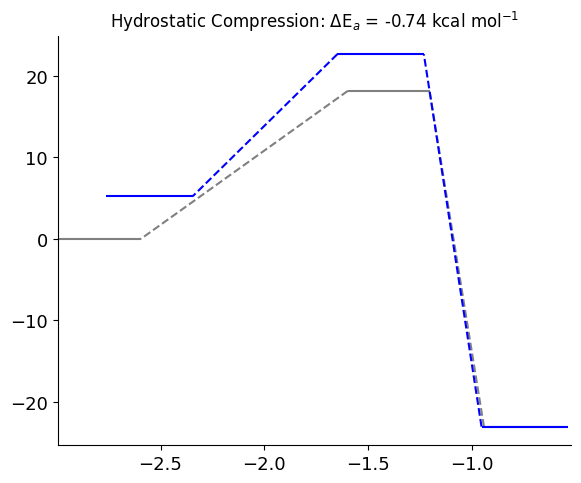

In [29]:
barrier = (
    (
        hydrostatic.force_modified_transition_state_energy - hydrostatic.force_modified_reactant_energy
    ) - (hydrostatic.transition_state_energy - hydrostatic.reactant_energy)
) * UnitsData.convert("Hartrees", "Kilocalories/Mole")
hydrostatic.plot_lines(product=prod, product_energy=prod.energy, bonds=[(0, 16), (3, 15)],
                   plot_label=fr"Hydrostatic Compression: $\Delta \text{{E}}_a$ = {barrier:.2f} kcal mol$^{{-1}}$"
                   )

How does the reactant complex respond to the force? Take some time to discuss with your neighbor

In [ ]:
show_animation(hydrostatic.animate_reactant_distortion())

How does the transition state complex respond?

In [ ]:
show_animation(hydrostatic.animate_ts_distortion())

Take a look at the following (low resolution) surface, the hydrostatic pressure is applied along each of these arrows. Does this make sense with the animations above?

In [ ]:
surf = hydrostatic.reactant.get_surface(samples=50).get_triangulation()
fig = hydrostatic.reactant.plot(backend='x3d')
show_graphics(surf.plot(solid=False, transparency=.7, normals=True, normal_scaling=-.2, figure=fig))

Finally, let's calculate the volume change of the reactant complex and transition state

In [37]:
v_ts = hydrostatic.transition_state.get_surface().volume()
v_r = hydrostatic.reactant.get_surface().volume()
v_fm_ts = hydrostatic.force_modified_transition_state.get_surface().volume()
v_fm_r = hydrostatic.force_modified_reactant.get_surface().volume()

In [38]:
(v_fm_r - v_r) * UnitsData.convert("BohrRadius", "Angstroms")**3

-3.108045393515641

In [39]:
(v_fm_ts - v_ts) * UnitsData.convert("BohrRadius", "Angstroms")**3

-2.559495917036358

### Uniaxial Compression

To compare to other possible ways force could theoretically impact reactions, we can apply pressure _uniaxially_ as well, let consider the case of applying a pressure along the reaction coordinate via two cylindrical drums (see the PowerPoint for details)

In [40]:
uniaxial = rda.ForceModifiedReactionAnalyzer.from_data(
    utils.read_namedtuple('methacrylate_fmrd_cylinder.npz')
)

Let's make the same plots as before

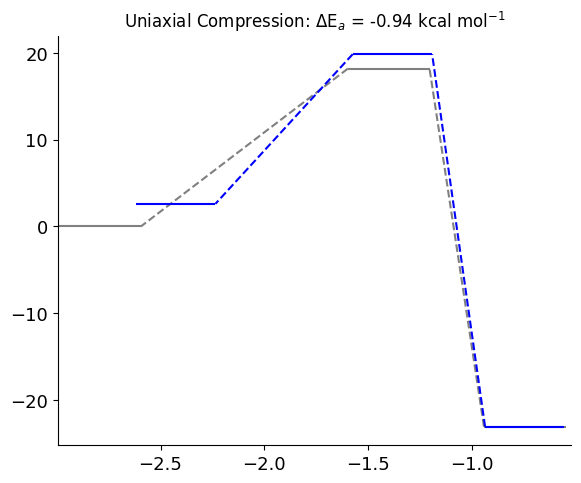

In [41]:
barrier_u = (
    (
        uniaxial.force_modified_transition_state_energy - uniaxial.force_modified_reactant_energy
    ) - (uniaxial.transition_state_energy - uniaxial.reactant_energy)
) * UnitsData.convert("Hartrees", "Kilocalories/Mole")
uniaxial.plot_lines(product=prod, product_energy=prod.energy, bonds=[(0, 16), (3, 15)],
                   plot_label=fr"Uniaxial Compression: $\Delta \text{{E}}_a$ = {barrier_u:.2f} kcal mol$^{{-1}}$"
                   )

In [42]:
show_animation(uniaxial.animate_reactant_distortion())

In [43]:
show_animation(uniaxial.animate_ts_distortion())

What is different from the hydrostatic case?

Finally, let's look at that volume change once again

In [44]:
u_ts = uniaxial.transition_state.get_surface().volume()
u_r = uniaxial.reactant.get_surface().volume()
u_fm_ts = uniaxial.force_modified_transition_state.get_surface().volume()
u_fm_r = uniaxial.force_modified_reactant.get_surface().volume()

In [45]:
(u_fm_r - u_r) * UnitsData.convert("BohrRadius", "Angstroms")**3

-1.30403786142015

In [46]:
(u_fm_ts - u_ts) * UnitsData.convert("BohrRadius", "Angstroms")**3

-0.7210281340009278

### Twisting

Finally, we can consider not just _compressions_, but also twisting. We've prepared a large dataset of molecules where we've twisted various parts of the system. Let's look at one

In [47]:
d2_int2 = rda.BarrierHeightDataset.from_tree(
    pipeline.read_compressed_pipeline_data('d2_int_partial.npz')
)
subds = d2_int2[
    lambda d: d['delta_transition_state'] > -.05,
    lambda d: d['delta_reactant'] > -.05,
    lambda d: d['delta'] < -1,
]
prod_t = subds[0].product
twist = subds.load_fmra(0)

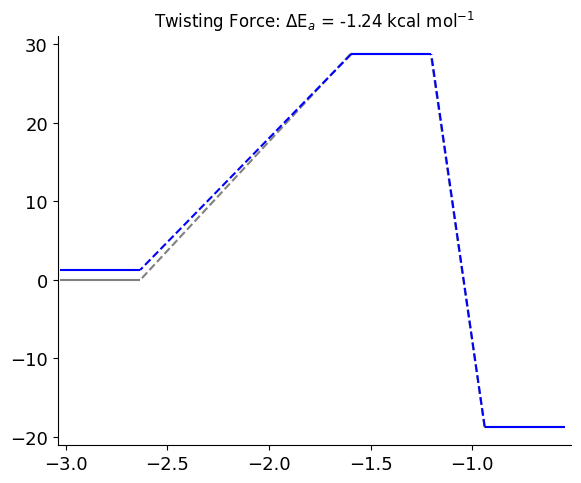

In [48]:
barrier_t = (
    (
         twist.force_modified_transition_state_energy - twist.force_modified_reactant_energy
    ) - (twist.transition_state_energy - twist.reactant_energy)
) * UnitsData.convert("Hartrees", "Kilocalories/Mole")
twist.plot_lines(product=prod_t, product_energy=prod_t.energy,
    plot_label=fr"Twisting Force: $\Delta \text{{E}}_a$ = {barrier_t:.2f} kcal mol$^{{-1}}$"

)

Compare this to the previous compression cases, notice anything different?

Let's also look at the molecular distortions

In [49]:
show_animation(twist.animate_reactant_distortion())

In [50]:
show_animation(twist.animate_ts_distortion())

A last, another look at volume changes

In [51]:
t_ts = twist.transition_state.get_surface().volume()
t_r = twist.reactant.get_surface().volume()
t_fm_ts = twist.force_modified_transition_state.get_surface().volume()
t_fm_r = twist.force_modified_reactant.get_surface().volume()

In [52]:
(t_fm_r - t_r) * UnitsData.convert("BohrRadius", "Angstroms")**3

-0.22521411291410198

In [53]:
(t_fm_ts - t_ts) * UnitsData.convert("BohrRadius", "Angstroms")**3

-0.05606636629818347